# Versão 4 - Teste Streaming Multi-step

O teste da versão 4 preserva a principal vitória de engenharia da versão 3: a inferência em streaming, sem materializar um dataframe gigante em memória. A diferença é que agora a avaliação fica mais rica, porque além das métricas globais nós também acompanhamos:

- métricas por variável;
- métricas por classe;
- métricas por poço;
- métricas por série;
- métricas por passo do horizonte de previsão.

Isso deixa mais fácil responder onde o modelo realmente melhora e onde a baseline de persistência ainda continua forte.


## 1. Configuração do ambiente e do experimento

Primeiro vamos carregar o bundle da versão 4, ler o resumo de comparação dos modelos treinados e escolher qual checkpoint será avaliado no teste.


In [1]:
from __future__ import annotations

#resolve os caminhos para importar o pipeline_v4 de forma robusta
from pathlib import Path
import sys
import json
import math

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao4",
    CURRENT_DIR.parent / "versao4",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v4.py").exists()), CURRENT_DIR)
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "versao4" else NOTEBOOK_DIR
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

#carrega bibliotecas para graficos, tensores e tabelas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from IPython.display import display

#importa as funcoes usadas no fluxo de teste da versao4
from pipeline_v4 import (
    GroupedWindowDataset,
    count_group_windows,
    export_streaming_result_tables,
    limit_groups_for_inference,
    load_bundle,
    load_grouped_sequences_from_directory,
    load_model_from_config,
    predict_loader_streaming,
    set_seed,
)

#fixa a semente para manter reproducibilidade do preview e das amostras locais
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)


In [2]:
#define os caminhos dos artefatos gerados nas etapas anteriores
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V4_DIR = ARTIFACTS_DIR / "preprocessed_v4"
BUNDLE_PATH = PREPROCESSED_V4_DIR / "preprocessing_bundle_v4.json"
REPORTS_V4_DIR = ARTIFACTS_DIR / "reports_v4"
TRAINING_SUMMARY_PATH = REPORTS_V4_DIR / "model_comparison_v4.csv"
TEST_REPORTS_DIR = REPORTS_V4_DIR / "test_v4"
TEST_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

#permite escolher o modelo vencedor automaticamente ou selecionar um nome especifico
MODEL_SELECTION = "champion"

#parametros principais do teste
BATCH_SIZE = 384
NUM_WORKERS = 4
MAX_SERIES = None
MAX_BATCHES = None
MAX_WINDOWS = None
PROGRESS_EVERY = 25
PREVIEW_ROWS = 4096
PLOT_SAMPLE_ROWS = 500
USE_AMP = torch.cuda.is_available()

#parametros opcionais para exportacao em parquet por partes
ENABLE_EXPORT = False
EXPORT_SCALE = "original"
EXPORT_CHUNK_ROWS = 250_000
EXPORT_PARTITION_BY = None
EXPORT_DIR = ARTIFACTS_DIR / "predictions_v4_streaming"

#seleciona gpu quando disponivel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config_df = pd.DataFrame(
    {
        "configuracao": [
            "device",
            "model_selection",
            "batch_size",
            "num_workers",
            "max_series",
            "max_batches",
            "max_windows",
            "progress_every",
            "preview_rows",
            "use_amp",
            "enable_export",
            "export_scale",
            "export_chunk_rows",
            "export_partition_by",
        ],
        "valor": [
            str(device),
            MODEL_SELECTION,
            BATCH_SIZE,
            NUM_WORKERS,
            MAX_SERIES,
            MAX_BATCHES,
            MAX_WINDOWS,
            PROGRESS_EVERY,
            PREVIEW_ROWS,
            USE_AMP,
            ENABLE_EXPORT,
            EXPORT_SCALE,
            EXPORT_CHUNK_ROWS,
            EXPORT_PARTITION_BY,
        ],
    }
)
display(config_df)


,configuracao,valor
0,device,cuda
1,model_selection,champion
2,batch_size,384
3,num_workers,4
4,max_series,None
5,max_batches,None
6,max_windows,None
7,progress_every,25
8,preview_rows,4096
9,use_amp,True


## 2. Carga do modelo escolhido e dos dados de teste

O notebook lê o resumo de treino salvo no notebook anterior. Se `MODEL_SELECTION = "champion"`, o modelo com melhor validação em relação à persistência é carregado automaticamente.


In [3]:
#carrega o bundle e o resumo de comparacao dos modelos treinados
bundle = load_bundle(BUNDLE_PATH)
comparison_df = pd.read_csv(TRAINING_SUMMARY_PATH)

if MODEL_SELECTION == "champion":
    selected_row = comparison_df.sort_values(["best_ratio_to_persistence", "best_val_mae"]).iloc[0]
else:
    selected_candidates = comparison_df.loc[comparison_df["model_name"] == MODEL_SELECTION]
    if selected_candidates.empty:
        raise ValueError(f"Modelo {MODEL_SELECTION} nao encontrado em {TRAINING_SUMMARY_PATH}.")
    selected_row = selected_candidates.iloc[0]

model_config = json.loads(Path(selected_row["config_path"]).read_text())
model = load_model_from_config(
    model_config=model_config,
    well_count=max(len(bundle.well_to_id), 1),
    device=device,
)

#carrega todas as series processadas de teste
all_test_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V4_DIR / "test",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)
test_groups = limit_groups_for_inference(all_test_groups, max_series=MAX_SERIES)

#monta o dataset de janelas e o dataloader para iterar lote a lote
test_dataset = GroupedWindowDataset(
    groups=test_groups,
    sequence_length=model_config["sequence_length"],
    forecast_horizon=model_config["forecast_horizon"],
    sampled_windows=None,
    seed=999,
    balance_by_class=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    persistent_workers=NUM_WORKERS > 0,
)

#estima o volume total de janelas e batches antes da inferencia
estimated_windows = count_group_windows(
    test_groups,
    sequence_length=model_config["sequence_length"],
    forecast_horizon=model_config["forecast_horizon"],
)
if MAX_WINDOWS is not None:
    estimated_windows = min(estimated_windows, MAX_WINDOWS)
if MAX_BATCHES is not None:
    estimated_windows = min(estimated_windows, MAX_BATCHES * BATCH_SIZE)
estimated_batches = math.ceil(estimated_windows / BATCH_SIZE) if estimated_windows else 0

runtime_df = pd.DataFrame(
    {
        "aspecto": [
            "selected_model_name",
            "display_name",
            "sequence_length",
            "forecast_horizon",
            "series_de_teste_total",
            "series_de_teste_utilizadas",
            "janelas_estimadas",
            "batches_estimados",
        ],
        "valor": [
            model_config["model_name"],
            model_config.get("display_name", model_config["model_name"]),
            model_config["sequence_length"],
            model_config["forecast_horizon"],
            len(all_test_groups),
            len(test_groups),
            estimated_windows,
            estimated_batches,
        ],
    }
)
display(runtime_df)


,aspecto,valor
0,selected_model_name,pure_lstm_forecaster_v4
1,display_name,LSTM pura
2,sequence_length,60
3,forecast_horizon,5
4,series_de_teste_total,360
5,series_de_teste_utilizadas,360
6,janelas_estimadas,12381947
7,batches_estimados,32245


## 3. Inferência streaming

A execução abaixo percorre o conjunto de teste em lotes. O resultado principal não é um dataframe gigante em memória, e sim um objeto com métricas agregadas, preview opcional e caminhos de exportação, caso a escrita em Parquet esteja habilitada.


In [4]:
#executa a inferencia em streaming para evitar um dataframe gigante em memoria
streaming_result = predict_loader_streaming(
    model=model,
    loader=test_loader,
    device=device,
    raw_target_positions=model_config["raw_target_positions"],
    groups=test_groups,
    bundle=bundle,
    collect_metrics=True,
    export_predictions=ENABLE_EXPORT,
    export_dir=EXPORT_DIR if ENABLE_EXPORT else None,
    export_chunk_rows=EXPORT_CHUNK_ROWS,
    export_scale=EXPORT_SCALE,
    export_partition_by=EXPORT_PARTITION_BY,
    preview_rows=PREVIEW_ROWS,
    max_batches=MAX_BATCHES,
    max_windows=MAX_WINDOWS,
    max_series=MAX_SERIES,
    progress_every=PROGRESS_EVERY,
    log_memory=True,
    model_label=model_config.get("display_name", model_config["model_name"]),
    baseline_label="Persistencia",
    use_amp=USE_AMP,
)

#mantem apenas uma amostra pequena em memoria para inspecao visual posterior
preview_df = streaming_result.preview_df.copy() if streaming_result.preview_df is not None else pd.DataFrame()

inference_summary_df = pd.DataFrame(
    {
        "aspecto": [
            "processed_batches",
            "processed_windows",
            "total_batches_estimate",
            "total_windows_estimate",
            "elapsed_seconds",
            "preview_rows_retained",
            "export_files",
        ],
        "valor": [
            streaming_result.processed_batches,
            streaming_result.processed_windows,
            streaming_result.total_batches_estimate,
            streaming_result.total_windows_estimate,
            round(streaming_result.elapsed_seconds, 2),
            len(preview_df),
            len(streaming_result.export_files),
        ],
    }
)
display(inference_summary_df)

if not preview_df.empty:
    display(preview_df.head())
else:
    print("Nenhuma linha foi mantida para preview. Aumente PREVIEW_ROWS se quiser inspecionar amostras.")


[predict_loader_streaming_v4] batch 25/32245 | janelas 9,600/12,381,947 (  0.1%) | tempo 00:01 | eta 12:43 | ultimo_batch 0.008s | mem 4,468 MB
[predict_loader_streaming_v4] batch 50/32245 | janelas 19,200/12,381,947 (  0.2%) | tempo 00:01 | eta 08:40 | ultimo_batch 0.009s | mem 4,468 MB
[predict_loader_streaming_v4] batch 75/32245 | janelas 28,800/12,381,947 (  0.2%) | tempo 00:01 | eta 07:24 | ultimo_batch 0.008s | mem 4,468 MB
[predict_loader_streaming_v4] batch 100/32245 | janelas 38,400/12,381,947 (  0.3%) | tempo 00:01 | eta 06:44 | ultimo_batch 0.008s | mem 4,468 MB
[predict_loader_streaming_v4] batch 125/32245 | janelas 48,000/12,381,947 (  0.4%) | tempo 00:01 | eta 06:17 | ultimo_batch 0.010s | mem 4,468 MB
[predict_loader_streaming_v4] batch 150/32245 | janelas 57,600/12,381,947 (  0.5%) | tempo 00:02 | eta 05:56 | ultimo_batch 0.007s | mem 4,468 MB
[predict_loader_streaming_v4] batch 175/32245 | janelas 67,200/12,381,947 (  0.5%) | tempo 00:02 | eta 05:40 | ultimo_batch 0.00

,aspecto,valor
0,processed_batches,32245.00
1,processed_windows,12381947.00
2,total_batches_estimate,32245.00
3,total_windows_estimate,12381947.00
4,elapsed_seconds,241.85
5,preview_rows_retained,4096.00
6,export_files,0.00


,series_id,well_name,class_label,source_type,step_idx,horizon_step,timestamp,real__P-ANULAR,pred__P-ANULAR,persist__P-ANULAR,real__P-JUS-CKGL,pred__P-JUS-CKGL,persist__P-JUS-CKGL,real__P-MON-CKP,pred__P-MON-CKP,persist__P-MON-CKP,real__P-TPT,pred__P-TPT,persist__P-TPT,real__T-JUS-CKP,pred__T-JUS-CKP,persist__T-JUS-CKP,real__T-TPT,pred__T-TPT,persist__T-TPT,real_scaled__P-ANULAR,pred_scaled__P-ANULAR,persist_scaled__P-ANULAR,real_scaled__P-JUS-CKGL,pred_scaled__P-JUS-CKGL,persist_scaled__P-JUS-CKGL,real_scaled__P-MON-CKP,pred_scaled__P-MON-CKP,persist_scaled__P-MON-CKP,real_scaled__P-TPT,pred_scaled__P-TPT,persist_scaled__P-TPT,real_scaled__T-JUS-CKP,pred_scaled__T-JUS-CKP,persist_scaled__T-JUS-CKP,real_scaled__T-TPT,pred_scaled__T-TPT,persist_scaled__T-TPT
0,0__WELL-00001_20170825110000,WELL-00001,0,well,60,1,2017-08-25 11:01:00,11499810.0,11499873.0,11499840.0,-142576.906250,-142266.734375,-142576.609375,1391547.0,1391100.500,1388785.0,9665080.0,9664341.0,9665121.0,83.250069,83.194077,83.238869,118.473404,118.474976,118.473404,0.780032,0.780036,0.780034,-0.039027,-0.038942,-0.039027,-0.147942,-0.148031,-0.148496,-0.567496,-0.567582,-0.567491,0.200411,0.199710,0.200271,0.129783,0.129810,0.129783
1,0__WELL-00001_20170825110000,WELL-00001,0,well,61,2,2017-08-25 11:01:01,11499770.0,11500310.0,11499840.0,-142577.296875,-141959.046875,-142576.609375,1394309.0,1393515.750,1388785.0,9665040.0,9662277.0,9665121.0,83.261276,83.157211,83.238869,118.473404,118.486839,118.473404,0.780029,0.780066,0.780034,-0.039027,-0.038857,-0.039027,-0.147387,-0.147546,-0.148496,-0.567501,-0.567821,-0.567491,0.200551,0.199249,0.200271,0.129783,0.130013,0.129783
2,0__WELL-00001_20170825110000,WELL-00001,0,well,62,3,2017-08-25 11:01:02,11499730.0,11499727.0,11499840.0,-142577.593750,-141645.484375,-142576.609375,1397071.0,1395972.500,1388785.0,9664999.0,9659803.0,9665121.0,83.272476,83.129845,83.238869,118.473404,118.493309,118.473404,0.780027,0.780026,0.780034,-0.039027,-0.038772,-0.039027,-0.146832,-0.147053,-0.148496,-0.567505,-0.568108,-0.567491,0.200691,0.198907,0.200271,0.129783,0.130124,0.129783
3,0__WELL-00001_20170825110000,WELL-00001,0,well,63,4,2017-08-25 11:01:03,11499700.0,11500092.0,11499840.0,-142578.000000,-141344.109375,-142576.609375,1399833.0,1399381.125,1388785.0,9664958.0,9657693.0,9665121.0,83.283684,83.111237,83.238869,118.473404,118.498711,118.473404,0.780025,0.780051,0.780034,-0.039027,-0.038689,-0.039027,-0.146277,-0.146368,-0.148496,-0.567510,-0.568352,-0.567491,0.200831,0.198674,0.200271,0.129783,0.130217,0.129783
4,0__WELL-00001_20170825110000,WELL-00001,0,well,64,5,2017-08-25 11:01:04,11499660.0,11500667.0,11499840.0,-142578.296875,-141206.484375,-142576.609375,1402595.0,1400226.125,1388785.0,9664918.0,9655538.0,9665121.0,83.294876,83.096138,83.238869,118.473404,118.505814,118.473404,0.780022,0.780090,0.780034,-0.039027,-0.038651,-0.039027,-0.145722,-0.146198,-0.148496,-0.567515,-0.568602,-0.567491,0.200971,0.198485,0.200271,0.129783,0.130338,0.129783


### Leitura desta execução

O teste completo processou `12.381.947` janelas em `32.245` batches e terminou em aproximadamente `241,85` segundos. Como cada janela gera `5` previsões futuras, isso corresponde a cerca de `61.909.735` previsões no nível linha a linha.

Os logs de memória ficaram em torno de `4,47 GB` durante a execução. Esse ponto é central: mesmo com horizonte multi-step, a estratégia streaming continuou tornando o teste viável sem explodir o uso de RAM.


### Como interpretar a execução

Se a memória do processo permanecer estável e o número de janelas processadas crescer continuamente, significa que a estratégia streaming está funcionando como planejado. O tempo total passa a depender mais do custo de leitura, preparação dos lotes e inferência em GPU do que do `pandas` tentando segurar milhões de linhas ao mesmo tempo.


## 4. Métricas globais e exportação dos relatórios

Primeiro vamos olhar o quadro agregado. Depois, salvaremos em CSV as tabelas detalhadas para consulta externa.


In [5]:
#recupera as metricas agregadas e salva tabelas auxiliares em csv
global_metrics_scaled_df = streaming_result.global_metrics_scaled_df.copy() if streaming_result.global_metrics_scaled_df is not None else pd.DataFrame()
global_metrics_original_df = streaming_result.global_metrics_original_df.copy() if streaming_result.global_metrics_original_df is not None else pd.DataFrame()

saved_report_files = export_streaming_result_tables(
    streaming_result,
    output_dir=TEST_REPORTS_DIR,
    prefix=f"{model_config['model_name']}_teste",
)

print("Escala padronizada")
display(global_metrics_scaled_df if not global_metrics_scaled_df.empty else pd.DataFrame({"mensagem": ["Metricas indisponiveis."]}))
print("Escala original")
display(global_metrics_original_df if not global_metrics_original_df.empty else pd.DataFrame({"mensagem": ["Metricas indisponiveis."]}))
pd.DataFrame(
    {
        "relatorio": list(saved_report_files.keys()),
        "arquivo": list(saved_report_files.values()),
    }
)


Escala padronizada


,modelo,MSE,RMSE,MAE,R2_medio,mse_melhora_pct,rmse_melhora_pct,mae_melhora_pct
0,LSTM pura,0.000007,0.002591,0.000419,0.999981,40.399948,22.79893,9.70663
1,Persistencia,0.000011,0.003356,0.000464,0.999969,NaN,NaN,NaN


Escala original


,modelo,MSE,RMSE,MAE,R2_medio,mse_melhora_pct,rmse_melhora_pct,mae_melhora_pct
0,LSTM pura,2.170834e+08,14733.749968,1938.902067,0.999981,34.402169,19.007512,13.304547
1,Persistencia,3.309307e+08,18191.501833,2236.451849,0.999969,NaN,NaN,NaN


,relatorio,arquivo
0,global_scaled,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
1,global_original,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
2,per_feature_scaled,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
3,per_feature_original,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
4,class_scaled,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
5,class_original,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
6,well_scaled,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
7,well_original,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
8,series_scaled,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
9,series_original,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...


### Leitura do resultado global desta execução

Este foi o principal contraste em relação ao notebook de validação: a `LSTM pura` ainda parecia pior do que a persistência na validação amostrada, mas venceu a baseline no teste completo. Na escala original, a melhora foi de aproximadamente `13,30%` em MAE e `19,01%` em RMSE. Na escala padronizada, a melhora global também apareceu, com `9,71%` em MAE e `22,80%` em RMSE.

Para um iniciante, a lição é muito valiosa: a forma de avaliar importa muito. Um modelo pode parecer apenas mediano em uma validação amostrada e ainda assim entregar ganho real quando avaliamos o conjunto inteiro e nas unidades físicas originais do problema.


## 5. Métricas detalhadas por variável, classe, poço, série e horizonte

Esta é a parte que mais ajuda a transformar o teste em diagnóstico. Em vez de olhar apenas uma média global, vamos identificar exatamente onde o modelo melhora e onde a persistência ainda continua forte.


In [6]:
#recupera as metricas detalhadas produzidas durante a inferencia streaming
per_feature_original_df = streaming_result.per_feature_original_df.copy() if streaming_result.per_feature_original_df is not None else pd.DataFrame()
class_metrics_original_df = streaming_result.class_metrics_original_df.copy() if streaming_result.class_metrics_original_df is not None else pd.DataFrame()
well_metrics_original_df = streaming_result.well_metrics_original_df.copy() if streaming_result.well_metrics_original_df is not None else pd.DataFrame()
series_metrics_original_df = streaming_result.series_metrics_original_df.copy() if streaming_result.series_metrics_original_df is not None else pd.DataFrame()
horizon_metrics_original_df = streaming_result.horizon_metrics_original_df.copy() if streaming_result.horizon_metrics_original_df is not None else pd.DataFrame()

#destaca partes do problema em que a persistencia ainda vence ou onde os erros continuam mais altos
#o resumo abaixo deixa explicito que uma melhora global nao implica melhora uniforme em todas as fatias do problema
persistence_wins_df = per_feature_original_df.loc[per_feature_original_df["mae_melhora_pct"] < 0].copy()
hardest_classes_df = class_metrics_original_df.sort_values("model_MAE", ascending=False).head(10)
hardest_wells_df = well_metrics_original_df.sort_values("model_MAE", ascending=False).head(10)
hardest_series_df = series_metrics_original_df.sort_values("model_MAE", ascending=False).head(10)

print("Por feature")
display(per_feature_original_df if not per_feature_original_df.empty else pd.DataFrame({"mensagem": ["Metricas por feature indisponiveis."]}))
print("Features em que a persistencia ainda vence")
display(persistence_wins_df if not persistence_wins_df.empty else pd.DataFrame({"mensagem": ["Nenhuma feature com persistencia melhor no MAE."]}))
print("Classes mais dificeis")
display(hardest_classes_df if not hardest_classes_df.empty else pd.DataFrame({"mensagem": ["Metricas por classe indisponiveis."]}))
print("Pocos mais dificeis")
display(hardest_wells_df if not hardest_wells_df.empty else pd.DataFrame({"mensagem": ["Metricas por poco indisponiveis."]}))
print("Series mais dificeis")
display(hardest_series_df if not hardest_series_df.empty else pd.DataFrame({"mensagem": ["Metricas por serie indisponiveis."]}))
print("Desempenho por passo do horizonte")
display(horizon_metrics_original_df if not horizon_metrics_original_df.empty else pd.DataFrame({"mensagem": ["Metricas por horizonte indisponiveis."]}))


Por feature


,feature,model_mae,baseline_mae,mae_melhora_pct,model_mse,baseline_mse,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
0,P-MON-CKP,8551.241572,10627.307555,19.535202,8.850189e+08,1.544894e+09,29749.267889,39305.134475,24.312006,0.999901,0.999827,-1042.021732,29731.012943
1,P-ANULAR,1204.580857,750.558634,-60.491240,3.885213e+08,3.880618e+08,19710.944487,19699.285491,-0.059185,0.999994,0.999994,301.984893,19708.631046
2,P-TPT,1471.968879,1667.590841,11.730813,1.955446e+07,4.262903e+07,4422.042226,6529.091056,32.271702,1.000000,0.999999,45.465259,4421.808494
3,P-JUS-CKGL,405.590506,373.232910,-8.669545,9.405599e+06,9.999959e+06,3066.854859,3162.271133,3.017334,1.000000,1.000000,-65.113257,3066.163562
4,T-JUS-CKP,0.019870,0.013032,-52.474756,6.746397e-03,8.463590e-03,0.082136,0.091998,10.719086,0.999994,0.999993,0.001267,0.082127
5,T-TPT,0.010716,0.008125,-31.888366,2.547388e-03,2.712086e-03,0.050472,0.052078,3.083928,0.999999,0.999999,0.001905,0.050436


Features em que a persistencia ainda vence


,feature,model_mae,baseline_mae,mae_melhora_pct,model_mse,baseline_mse,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
1,P-ANULAR,1204.580857,750.558634,-60.491240,3.885213e+08,3.880618e+08,19710.944487,19699.285491,-0.059185,0.999994,0.999994,301.984893,19708.631046
3,P-JUS-CKGL,405.590506,373.232910,-8.669545,9.405599e+06,9.999959e+06,3066.854859,3162.271133,3.017334,1.000000,1.000000,-65.113257,3066.163562
4,T-JUS-CKP,0.019870,0.013032,-52.474756,6.746397e-03,8.463590e-03,0.082136,0.091998,10.719086,0.999994,0.999993,0.001267,0.082127
5,T-TPT,0.010716,0.008125,-31.888366,2.547388e-03,2.712086e-03,0.050472,0.052078,3.083928,0.999999,0.999999,0.001905,0.050436


Classes mais dificeis


...

,well_name,model_MAE,baseline_MAE,mae_melhora_pct,model_RMSE,baseline_RMSE,rmse_melhora_pct,model_R2,baseline_R2,linhas_avaliadas
18,WELL-00024,14107.533277,21228.858118,33.545492,47108.489463,65593.459814,28.181118,9.837931e-01,0.969839,3041600
23,WELL-00036,8002.945519,8676.191516,7.759695,27000.637947,32749.601391,17.554301,8.958926e-01,0.951878,53020
2,WELL-00001,7704.672788,7368.876999,-4.556947,25066.728264,26261.512122,4.549562,9.997179e-01,0.999769,1926850
12,WELL-00014,5767.206834,5769.646446,0.042284,63862.014656,63956.932646,0.148409,9.974588e-01,0.997434,964340
22,WELL-00035,5331.474676,6173.358334,13.637369,18038.194680,20003.447899,9.824572,-5.617683e+21,0.999221,588380
14,WELL-00019,2937.687925,2537.075223,-15.790336,15871.558349,15815.559131,-0.354077,1.015962e-01,0.912219,1273700
16,WELL-00022,2273.972252,3098.307576,26.605987,4996.068053,7450.156549,32.940093,9.967457e-01,0.995701,3023535
15,WELL-00020,1954.186610,2885.798049,32.282628,8775.945435,11280.571249,22.203005,9.998179e-01,0.999575,311875
8,WELL-00007,1687.225617,1859.156676,9.247798,4075.088617,5399.110909,24.522969,9.968022e-01,0.998192,106950
13,WELL-00016,1590.689536,1659.476878,4.145122,4444.179579,5708.476863,22.147717,9.999911e-01,0.999989,162735


Series mais dificeis


,series_id,model_MAE,baseline_MAE,mae_melhora_pct,model_RMSE,baseline_RMSE,rmse_melhora_pct,model_R2,baseline_R2,linhas_avaliadas
350,9__WELL-00014_20170214190000,16110.290865,16032.863125,-0.482931,188410.214024,188420.020726,0.005205,0.989968,0.993860,107685
307,7__WELL-00024_20160923141645,15286.259505,22595.213474,32.347355,49687.285994,68501.310146,27.465203,0.895550,0.922164,280515
309,7__WELL-00024_20161001112049,14661.087512,21656.204372,32.300752,48824.723016,67133.181707,27.271847,0.974784,0.964126,929440
308,7__WELL-00024_20160926072123,14125.102622,21563.577126,34.495550,46670.474199,65887.622408,29.166553,0.980549,0.968485,946195
310,7__WELL-00024_20161026065657,13134.276896,19989.730752,34.294878,44846.417311,62634.860687,28.400228,0.971148,0.954043,885450
1,0__WELL-00001_20170825160000,9377.005560,9065.583825,-3.435209,28098.465019,29583.501585,5.019813,0.957615,0.973449,107095
12,0__WELL-00001_20170827230000,9296.444267,8941.097933,-3.974303,27989.193484,29277.343212,4.399818,0.487207,0.972117,106310
5,0__WELL-00001_20170826120000,9205.433179,8781.214280,-4.830982,27857.574581,28927.643639,3.699123,-1.493342,0.972911,107355
8,0__WELL-00001_20170827030000,9182.143901,8882.714748,-3.370919,27834.390550,29320.868255,5.069692,-1.271871,0.971433,107095
3,0__WELL-00001_20170826020000,9134.083160,8848.589682,-3.226429,27401.214687,28936.315116,5.305100,-0.220088,0.974092,107290


Desempenho por passo do horizonte


,horizon_step,model_MAE,baseline_MAE,mae_melhora_pct,model_RMSE,baseline_RMSE,rmse_melhora_pct,model_R2,baseline_R2,linhas_avaliadas
0,1,932.785268,1036.734132,10.026569,5658.171119,7137.549063,20.726694,0.999997,0.999995,12381947
1,2,1363.513705,1624.617632,16.071716,9125.193505,11908.378676,23.371655,0.999993,0.999986,12381947
2,3,1901.541120,2251.968252,15.560927,13332.303984,16988.372311,21.521004,0.999985,0.999972,12381947
3,4,2471.419570,2854.997820,13.435325,17654.785508,21849.534513,19.198345,0.999973,0.999955,12381947
4,5,3025.250671,3413.941411,11.385396,21924.668818,26379.777353,16.888348,0.999959,0.999935,12381947


### Síntese dos resultados detalhados desta execução

O ganho não foi uniforme. Em MAE, o modelo melhorou apenas `2` das `6` variáveis-alvo (`P-MON-CKP` e `P-TPT`), `4` das `10` classes, `14` dos `27` poços e `78` das `360` séries. Isso mostra que uma melhora global não significa que o modelo aprendeu igualmente bem todos os cenários.

A melhora forte em `P-MON-CKP`, que é uma variável de grande escala numérica, ajuda a explicar por que o MAE global caiu mesmo com perdas em variáveis menores, como `T-JUS-CKP` e `T-TPT`. Em outras palavras, algumas vitórias “pesam” mais no agregado do que outras derrotas.

Também vale notar que todos os `5` passos do horizonte superaram a persistência, com melhora de MAE entre aproximadamente `10,0%` e `16,1%`. O erro cresce à medida que o horizonte avança, o que é esperado, mas a vantagem sobre a baseline foi preservada em todos os passos.

Alguns subconjuntos exibiram valores estranhos de `R²`, inclusive números muito negativos em certos poços. Isso costuma acontecer quando a variância local é muito pequena ou quando a série tem comportamento quase constante. Nesses casos, `MAE` e `RMSE` são métricas mais confiáveis para diagnóstico local.


### Como ler as métricas por horizonte

Em previsão multi-step, é esperado que os passos mais distantes sejam mais difíceis. Por isso, uma tendência de aumento de MAE ou RMSE ao longo do horizonte não é necessariamente um problema por si só. O sinal preocupante é quando a degradação fica muito rápida ou quando a persistência passa a vencer claramente nos passos mais distantes.


## 6. Comparação entre validação e teste

Para fechar o ciclo experimental, vamos colocar lado a lado o melhor ponto de validação e o resultado observado no teste real.


In [7]:
#compara o resumo do treino com o resultado do teste para o modelo selecionado
selected_training_row_df = comparison_df.loc[comparison_df["model_name"] == model_config["model_name"]].copy()

if global_metrics_original_df.empty:
    final_summary_df = pd.DataFrame({"mensagem": ["Metricas globais indisponiveis."]})
else:
    model_test_row = global_metrics_original_df.iloc[0]
    final_summary_df = pd.DataFrame(
        {
            "aspecto": [
                "best_val_mae",
                "best_val_persistence_mae",
                "best_ratio_to_persistence",
                "test_mae",
                "test_rmse",
                "test_mae_improvement_pct",
            ],
            "valor": [
                float(selected_training_row_df.iloc[0]["best_val_mae"]),
                float(selected_training_row_df.iloc[0]["best_val_persistence_mae"]),
                float(selected_training_row_df.iloc[0]["best_ratio_to_persistence"]),
                float(model_test_row["MAE"]),
                float(model_test_row["RMSE"]),
                float(model_test_row.get("mae_melhora_pct", np.nan)),
            ],
        }
    )

display(final_summary_df)


,aspecto,valor
0,best_val_mae,0.000239
1,best_val_persistence_mae,0.000208
2,best_ratio_to_persistence,1.149055
3,test_mae,1938.902067
4,test_rmse,14733.749968
5,test_mae_improvement_pct,13.304547


### O que aprender com a divergência entre validação e teste

O notebook de treino escolheu a `LSTM pura` como o modelo menos fraco na validação, não como um modelo já melhor do que a persistência. O teste completo, por outro lado, mostrou ganho global real. A explicação mais provável é a combinação de três fatores: validação por amostragem, horizonte multi-step e agregação final em escala original, onde variáveis de pressão com maior amplitude influenciam mais o resultado total.

Isso é um ótimo estudo de caso para quem está aprendendo Machine Learning: se o critério de seleção não representa bem o uso final do modelo, a ordem dos modelos pode mudar quando saímos da validação e vamos para o teste. Uma versão futura do pipeline deveria incluir validação streaming completa e critérios de seleção mais próximos da métrica operacional final.


## 7. Visualizações de apoio

Os gráficos abaixo ajudam a enxergar o resultado de maneira qualitativa. Eles não substituem as tabelas, mas tornam mais fácil perceber padrões de erro e comportamento do horizonte de previsão.


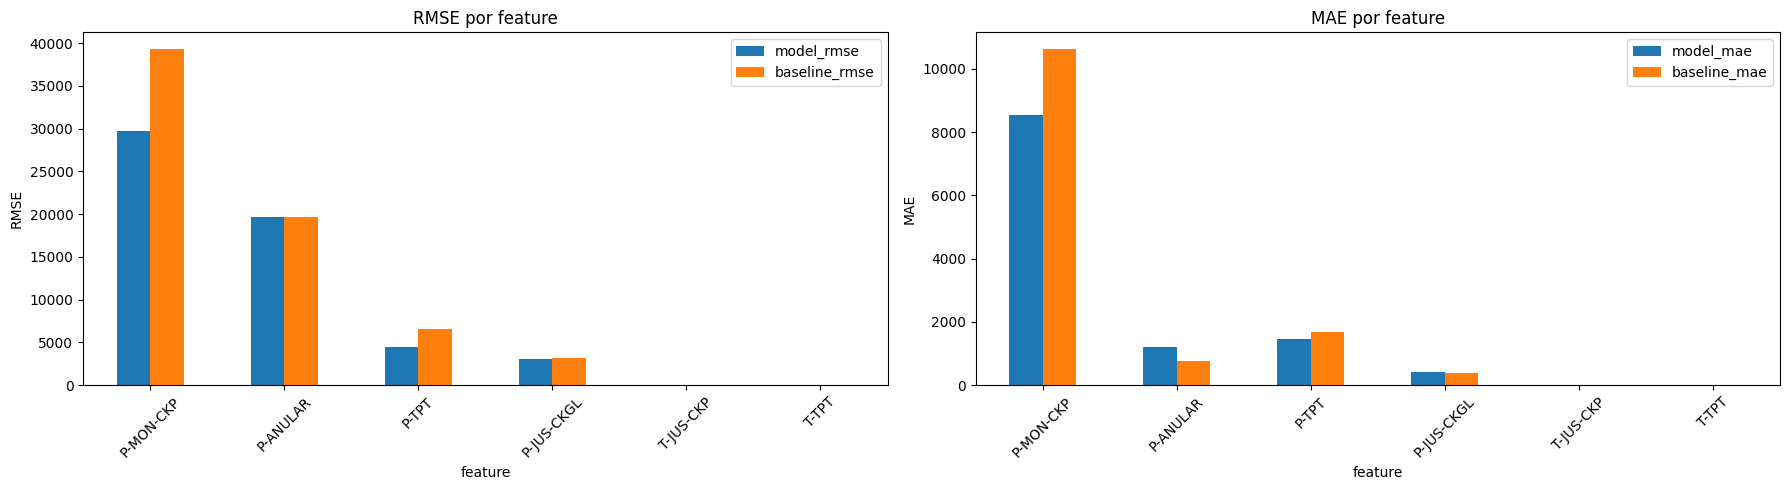

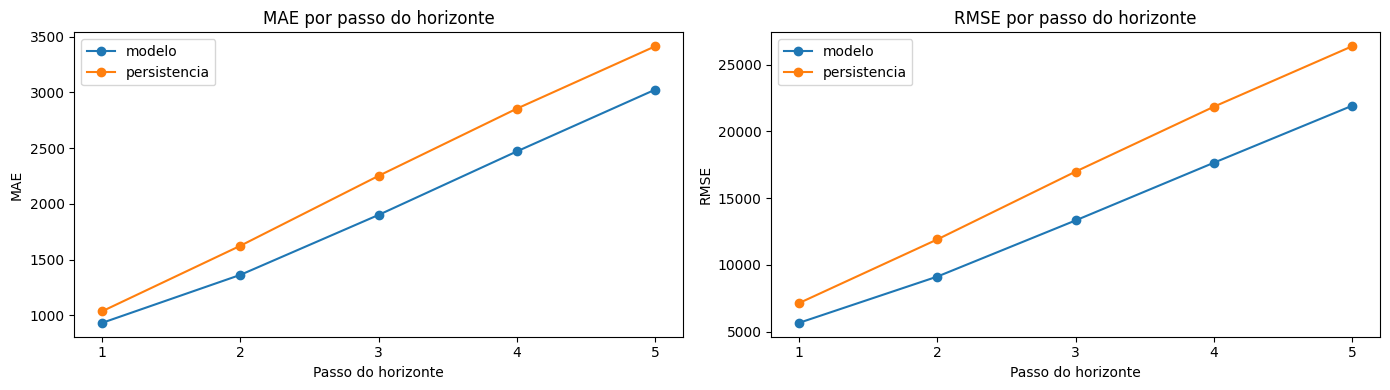

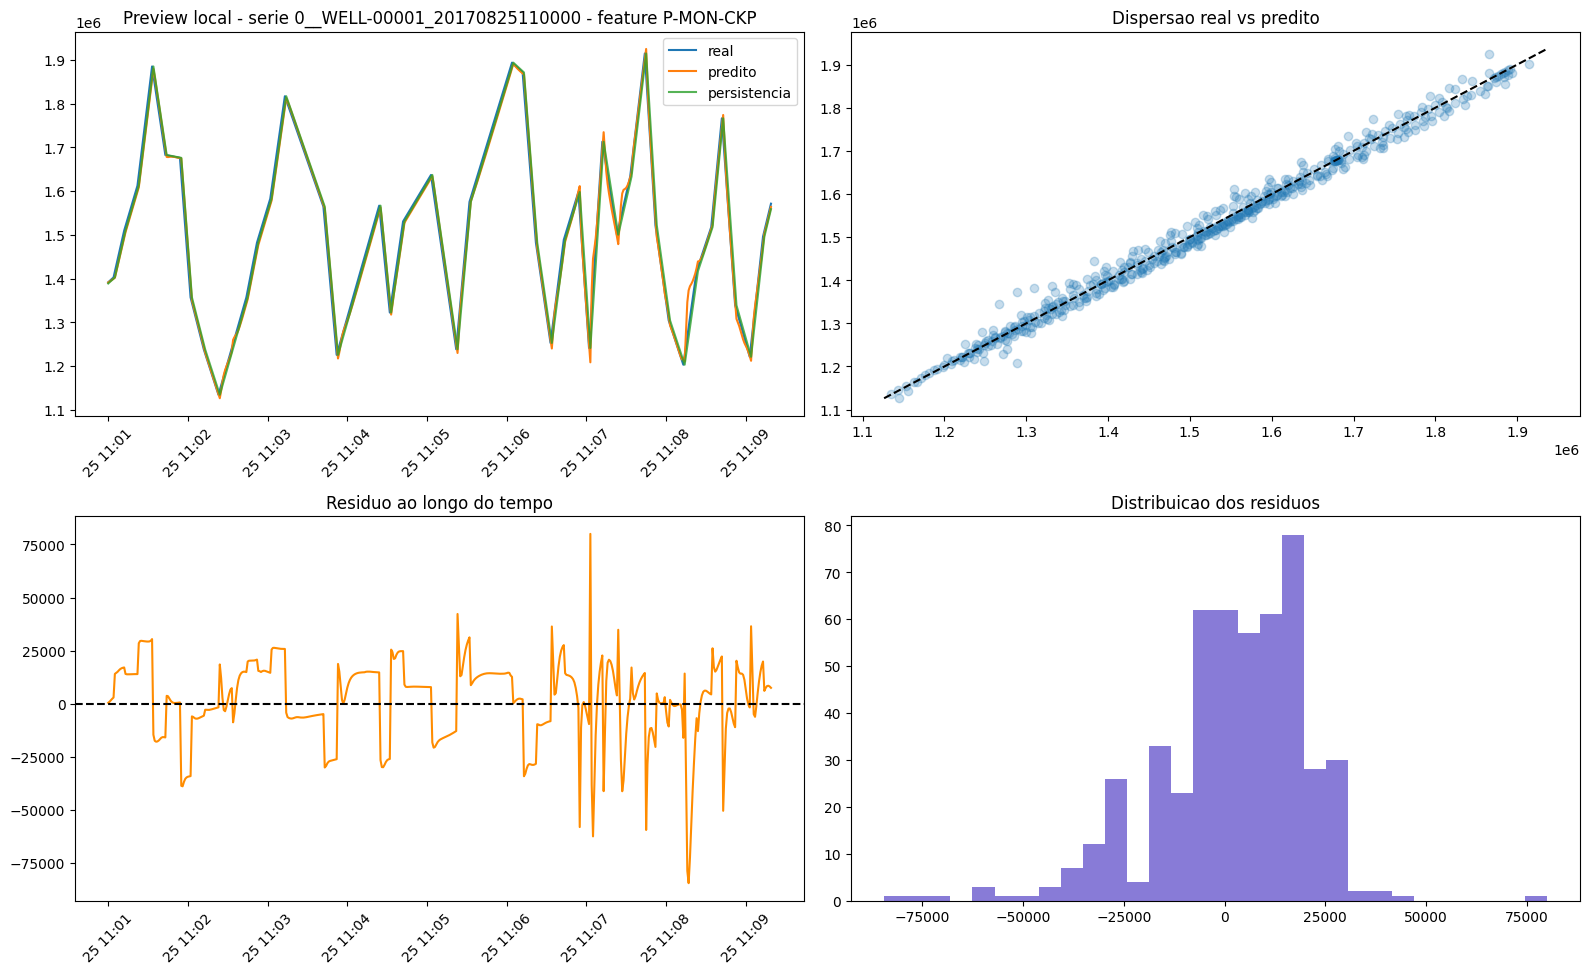

In [8]:
#gera comparativos graficos quando as metricas detalhadas estiverem disponiveis
if not per_feature_original_df.empty:
    compare_plot_df = per_feature_original_df.set_index("feature")

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    compare_plot_df[["model_rmse", "baseline_rmse"]].plot(kind="bar", ax=axes[0])
    axes[0].set_title("RMSE por feature")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=45)

    compare_plot_df[["model_mae", "baseline_mae"]].plot(kind="bar", ax=axes[1])
    axes[1].set_title("MAE por feature")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("As metricas por feature estao vazias. Nada para plotar nesse comparativo.")

if not horizon_metrics_original_df.empty:
    horizon_plot_df = horizon_metrics_original_df.sort_values("horizon_step").copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(horizon_plot_df["horizon_step"], horizon_plot_df["model_MAE"], marker="o", label="modelo")
    axes[0].plot(horizon_plot_df["horizon_step"], horizon_plot_df["baseline_MAE"], marker="o", label="persistencia")
    axes[0].set_title("MAE por passo do horizonte")
    axes[0].set_xlabel("Passo do horizonte")
    axes[0].set_ylabel("MAE")
    axes[0].legend()

    axes[1].plot(horizon_plot_df["horizon_step"], horizon_plot_df["model_RMSE"], marker="o", label="modelo")
    axes[1].plot(horizon_plot_df["horizon_step"], horizon_plot_df["baseline_RMSE"], marker="o", label="persistencia")
    axes[1].set_title("RMSE por passo do horizonte")
    axes[1].set_xlabel("Passo do horizonte")
    axes[1].set_ylabel("RMSE")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("As metricas por horizonte estao vazias. Nada para plotar nesse comparativo.")

if preview_df.empty:
    print("Preview vazio. Defina PREVIEW_ROWS > 0 para habilitar as visualizacoes locais.")
else:
    preview_series_id = preview_df["series_id"].iloc[0]
    focus_feature = per_feature_original_df.iloc[0]["feature"] if not per_feature_original_df.empty else bundle.target_columns[0]
    local_preview_df = preview_df[preview_df["series_id"] == preview_series_id].copy()
    local_preview_df = local_preview_df.sort_values(["timestamp", "horizon_step"]).reset_index(drop=True)
    local_preview_df = local_preview_df[local_preview_df["horizon_step"] == 1].copy()

    if local_preview_df.empty:
        print("Nao houve linhas suficientes do preview para plotar o primeiro passo do horizonte.")
    else:
        window_limit = min(PLOT_SAMPLE_ROWS, len(local_preview_df))
        real_local = local_preview_df[f"real__{focus_feature}"].to_numpy(dtype=np.float32)
        pred_local = local_preview_df[f"pred__{focus_feature}"].to_numpy(dtype=np.float32)
        persist_local = local_preview_df[f"persist__{focus_feature}"].to_numpy(dtype=np.float32)
        residual_local = real_local - pred_local

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes[0, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], real_local[:window_limit], label="real")
        axes[0, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], pred_local[:window_limit], label="predito")
        axes[0, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], persist_local[:window_limit], label="persistencia", alpha=0.8)
        axes[0, 0].set_title(f"Preview local - serie {preview_series_id} - feature {focus_feature}")
        axes[0, 0].tick_params(axis="x", rotation=45)
        axes[0, 0].legend()

        axes[0, 1].scatter(real_local[:window_limit], pred_local[:window_limit], alpha=0.25, label="modelo")
        min_axis = min(real_local.min(), pred_local.min(), persist_local.min())
        max_axis = max(real_local.max(), pred_local.max(), persist_local.max())
        axes[0, 1].plot([min_axis, max_axis], [min_axis, max_axis], color="black", linestyle="--")
        axes[0, 1].set_title("Dispersao real vs predito")

        axes[1, 0].plot(local_preview_df["timestamp"].iloc[:window_limit], residual_local[:window_limit], color="darkorange")
        axes[1, 0].axhline(0.0, color="black", linestyle="--")
        axes[1, 0].set_title("Residuo ao longo do tempo")
        axes[1, 0].tick_params(axis="x", rotation=45)

        axes[1, 1].hist(residual_local[:window_limit], bins=30, color="slateblue", alpha=0.8)
        axes[1, 1].set_title("Distribuicao dos residuos")

        plt.tight_layout()
        plt.show()


## Conclusão da etapa

A versão 4 mantém a eficiência de memória do teste da versão 3, mas transforma a avaliação em um relatório bem mais útil para tomada de decisão:

- se a persistência ainda vence em algumas features, isso aparece imediatamente;
- se o erro se concentra em certas classes ou poços, isso fica visível;
- se o modelo degrada rápido demais no horizonte, isso também fica claro.

Em outras palavras, a versão 4 não serve apenas para dizer se o modelo foi "bom" ou "ruim". Ela serve para mostrar **onde** ele foi bom, **onde** ainda falha e **qual** arquitetura vale a pena levar adiante.
